# 02 · Preprocessing & Feature Engineering

**Input:** `data/processed/cleaned_dataset.csv`  
**Outputs:** `data/processed/features_dataset.csv`, `data/processed/ml_ready_dataset.csv`  
**Models saved:** `models/scaler.pkl`, `models/encoders.pkl`, `models/model_feature_names.pkl`

**Design decisions:**
- Categorical columns encoded via Label Encoding (ordinal-like) and One-Hot Encoding (nominal)
- `price_per_sqft` — strongest price density signal
- `investment_score` — composite of financial scale + satisfaction
- `unit_type_encoded` — binary: Apartment=0, Office=1
- `loan_indicator` — binary: Yes=1, No=0
- All categoricals kept and encoded (PRD Step 2 compliance)

## 1 · Imports

In [29]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

pd.set_option('display.max_columns', None)
print('Libraries loaded')

Libraries loaded


## 2 · Load Cleaned Data

In [30]:
df = pd.read_csv('../data/processed/cleaned_dataset.csv')

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head()

Shape: (7305, 24)
Columns: ['client_id', 'client_type', 'first_name', 'last_name', 'date_of_birth', 'gender', 'country', 'region', 'acquisition_purpose', 'satisfaction_score', 'loan_applied', 'referral_channel', 'age', 'listing_id', 'tower_number', 'transaction_date', 'unit_category', 'unit_number', 'floor_area_sqft', 'sale_price', 'listing_status', 'age_group', 'price_segment', 'size_segment']


,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel,age,listing_id,tower_number,transaction_date,unit_category,unit_number,floor_area_sqft,sale_price,listing_status,age_group,price_segment,size_segment
0,C0001,Individual,Kareem,Liu,1968-05-11,F,USA,California,Home,4,Yes,Website,58,90343,9,2024-10-01,Apartment,40,1090.32,351419.29,Sold,Senior (46–60),Mid,Medium
1,C0001,Individual,Kareem,Liu,1968-05-11,F,USA,California,Home,4,Yes,Website,58,4051,4,2024-12-01,Apartment,51,1608.84,496266.41,Sold,Senior (46–60),Mid,Large
2,C0001,Individual,Kareem,Liu,1968-05-11,F,USA,California,Home,4,Yes,Website,58,150099,15,2025-05-01,Apartment,15,522.71,175599.90,Sold,Senior (46–60),Budget,Small
3,C0001,Individual,Kareem,Liu,1968-05-11,F,USA,California,Home,4,Yes,Website,58,30432,3,2025-12-01,Apartment,50,713.67,223479.12,Sold,Senior (46–60),Mid,Small
4,C0002,Individual,Trystan,Oconnor,1962-11-26,M,USA,California,Home,1,No,Website,64,150044,15,2024-01-01,Apartment,6,938.57,299245.20,Sold,Mature (60+),Mid,Medium


In [31]:
# Drop visualisation-only binning columns — not used in ML
df = df.drop(columns=['price_segment', 'size_segment', 'age_group'], errors='ignore')

print('Shape after dropping bin columns:', df.shape)
print('Missing values:')
print(df.isnull().sum())

Shape after dropping bin columns: (7305, 21)
Missing values:
client_id              0
client_type            0
first_name             0
last_name              0
date_of_birth          0
gender                 0
country                0
region                 0
acquisition_purpose    0
satisfaction_score     0
loan_applied           0
referral_channel       0
age                    0
listing_id             0
tower_number           0
transaction_date       0
unit_category          0
unit_number            0
floor_area_sqft        0
sale_price             0
listing_status         0
dtype: int64


## 3 · Feature Engineering

In [32]:
# Binary loan flag
df['loan_indicator'] = df['loan_applied'].map({'Yes': 1, 'No': 0})

# Price density — key separator between value and premium buyers
df['price_per_sqft'] = df['sale_price'] / df['floor_area_sqft']

# Investment score — combines financial scale with satisfaction signal
df['investment_score'] = (0.7 * (df['sale_price'] / df['sale_price'].max()) + 0.3 * (df['satisfaction_score'] / 5)) * 10

# Binary unit type — Apartment vs Office
df['unit_type_encoded'] = df['unit_category'].map({'Apartment': 0, 'Office': 1})

print('Engineered features added')
df[['sale_price', 'floor_area_sqft', 'price_per_sqft',
    'investment_score', 'loan_indicator', 'unit_type_encoded']].describe().round(2)

Engineered features added


,sale_price,floor_area_sqft,price_per_sqft,investment_score,loan_indicator,unit_type_encoded
count,7305.00,7305.00,7305.00,7305.00,7305.00,7305.00
mean,345072.00,1141.15,302.41,5.11,0.37,0.15
std,132053.77,419.24,30.00,1.51,0.48,0.35
min,97402.80,410.71,220.00,1.74,0.00,0.00
25%,232448.63,782.15,282.11,4.00,0.00,0.00
50%,330997.32,1110.88,301.74,5.04,0.00,0.00
75%,451237.67,1501.64,321.79,6.19,1.00,0.00
max,736652.27,1957.16,414.70,9.98,1.00,1.00


In [33]:
# Verify no nulls in engineered columns
engineered = ['loan_indicator', 'price_per_sqft', 'investment_score', 'unit_type_encoded']
print('Nulls in engineered columns:')
print(df[engineered].isnull().sum())

df = df.dropna(subset=engineered)
print('Shape after dropna:', df.shape)

Nulls in engineered columns:
loan_indicator       0
price_per_sqft       0
investment_score     0
unit_type_encoded    0
dtype: int64
Shape after dropna: (7305, 25)


## 4 · Categorical Encoding (PRD Step 2)

PRD requires encoding: `client_type`, `region`, `acquisition_purpose`, `referral_channel`, `country`, `gender`  
- **Label Encoding** for binary/ordinal fields  
- **One-Hot Encoding** for multi-class nominal fields

In [34]:
encoders = {}

# ── Label Encoding (binary / low-cardinality ordinal) ────────────────
label_encode_cols = ['client_type', 'gender', 'acquisition_purpose']

for col in label_encode_cols:
    le = LabelEncoder()
    df[f'{col}_encoded'] = le.fit_transform(df[col].astype(str))
    encoders[col] = le
    print(f'{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

print('\nLabel encoding done')

client_type: {'Company': np.int64(0), 'Individual': np.int64(1)}
gender: {'F': np.int64(0), 'M': np.int64(1)}
acquisition_purpose: {'Home': np.int64(0), 'Investment': np.int64(1)}

Label encoding done


In [35]:
# ── One-Hot Encoding (nominal multi-class) ───────────────────────────
ohe_cols = ['referral_channel', 'country', 'region']

ohe_dummies = pd.get_dummies(df[ohe_cols], drop_first=True, dtype=int)

# Store OHE column names in encoders dict for reference
for col in ohe_cols:
    encoders[f'{col}_ohe_cols'] = [c for c in ohe_dummies.columns if c.startswith(col)]

df = pd.concat([df, ohe_dummies], axis=1)

print('One-Hot Encoding done')
print('OHE columns added:', ohe_dummies.shape[1])
print(ohe_dummies.columns.tolist())

One-Hot Encoding done
OHE columns added: 67
['referral_channel_Client', 'referral_channel_Website', 'country_Belgium', 'country_Canada', 'country_Denmark', 'country_France', 'country_Germany', 'country_Mexico', 'country_Russia', 'country_UK', 'country_USA', 'region_Arizona', 'region_Baja California', 'region_Bavaria', 'region_Berlin', 'region_British Columbia', 'region_Brittany', 'region_Brussels', 'region_California', 'region_Capital Region', 'region_Central Denmark', 'region_Colorado', 'region_England', 'region_Flanders', 'region_Florida', 'region_Georgia', 'region_Hamburg', 'region_Hesse', 'region_Ile-de-France', 'region_Jalisco', 'region_Kansas', 'region_Krasnodar Krai', 'region_Manitoba', 'region_Mexico City', 'region_Moscow Oblast', 'region_Nevada', 'region_New South Wales', 'region_New York', 'region_Normandy', 'region_North Denmark', 'region_North Rhine-Westphalia', 'region_Northern Ireland', 'region_Novosibirsk', 'region_Nuevo Leon', 'region_Occitanie', 'region_Ohio', 'region_

In [36]:
# Save all encoders for use in the dashboard predict tab
joblib.dump(encoders, '../models/encoders.pkl')
print('encoders.pkl saved')

encoders.pkl saved


## 5 · Visualise Encoded Features

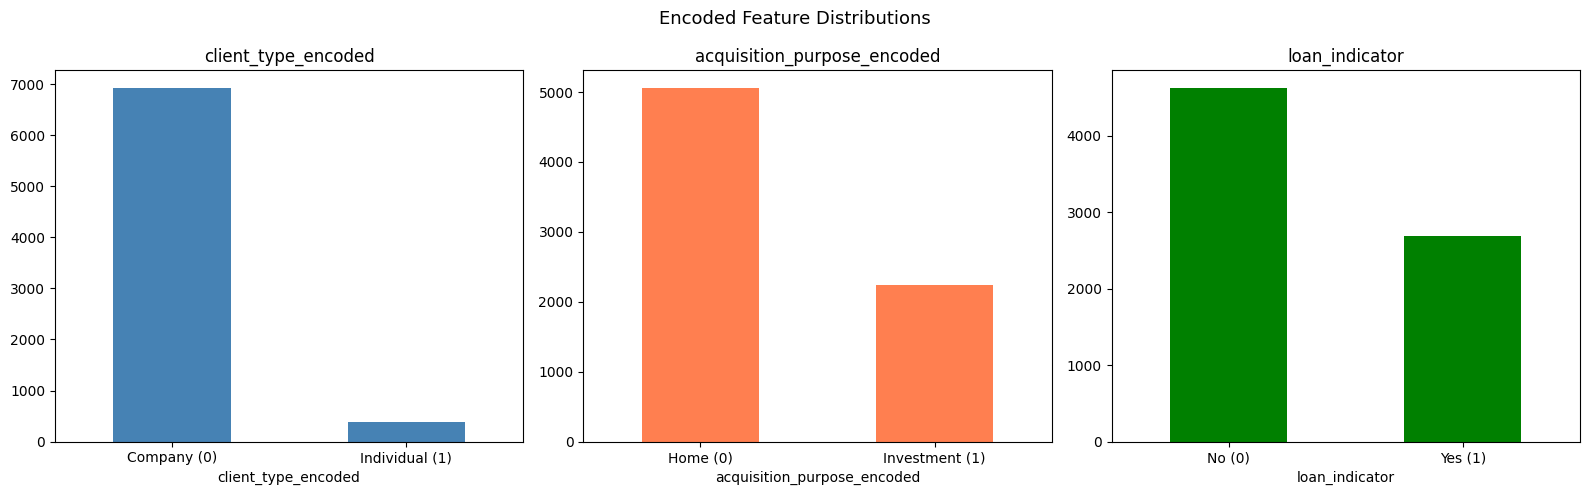

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# client_type_encoded
df['client_type_encoded'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('client_type_encoded')
axes[0].set_xticklabels(['Company (0)', 'Individual (1)'], rotation=0)

# acquisition_purpose_encoded
df['acquisition_purpose_encoded'].value_counts().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('acquisition_purpose_encoded')
axes[1].set_xticklabels(['Home (0)', 'Investment (1)'], rotation=0)

# loan_indicator
df['loan_indicator'].value_counts().plot(kind='bar', ax=axes[2], color='green')
axes[2].set_title('loan_indicator')
axes[2].set_xticklabels(['No (0)', 'Yes (1)'], rotation=0)

plt.suptitle('Encoded Feature Distributions', fontsize=13)
plt.tight_layout()
plt.show()

## 6 · Build Feature Dataset

In [38]:
# Core 8 features the clustering model trains on
MODEL_FEATURES = [
    'sale_price',
    'floor_area_sqft',
    'price_per_sqft',
    'investment_score',
    'loan_indicator',
    'satisfaction_score',
    'age',
    'unit_type_encoded',
]

# Display / context columns kept for dashboard
DISPLAY_COLS = [
    'client_id', 'country', 'region', 'unit_category',
    'acquisition_purpose', 'client_type', 'referral_channel',
    'gender', 'loan_applied', 'satisfaction_score'
]

features_df = df[MODEL_FEATURES + [c for c in DISPLAY_COLS if c not in MODEL_FEATURES]].copy()

print('Feature dataset shape:', features_df.shape)
print('Model feature columns:', MODEL_FEATURES)
features_df.head()

Feature dataset shape: (7305, 17)
Model feature columns: ['sale_price', 'floor_area_sqft', 'price_per_sqft', 'investment_score', 'loan_indicator', 'satisfaction_score', 'age', 'unit_type_encoded']


,sale_price,floor_area_sqft,price_per_sqft,investment_score,loan_indicator,satisfaction_score,age,unit_type_encoded,client_id,country,region,unit_category,acquisition_purpose,client_type,referral_channel,gender,loan_applied
0,351419.29,1090.32,322.308396,5.739344,1,4,58,0,C0001,USA,California,Apartment,Home,Individual,Website,F,Yes
1,496266.41,1608.84,308.462252,7.115746,1,4,58,0,C0001,USA,California,Apartment,Home,Individual,Website,F,Yes
2,175599.90,522.71,335.941344,4.068629,1,4,58,0,C0001,USA,California,Apartment,Home,Individual,Website,F,Yes
3,223479.12,713.67,313.140695,4.523599,1,4,58,0,C0001,USA,California,Apartment,Home,Individual,Website,F,Yes
4,299245.20,938.57,318.830988,3.443562,0,1,64,0,C0002,USA,California,Apartment,Home,Individual,Website,M,No


In [39]:
print('Dtypes of model features:')
print(features_df[MODEL_FEATURES].dtypes)
print('\nAny nulls in model features:')
print(features_df[MODEL_FEATURES].isnull().sum())

Dtypes of model features:
sale_price            float64
floor_area_sqft       float64
price_per_sqft        float64
investment_score      float64
loan_indicator          int64
satisfaction_score      int64
age                     int64
unit_type_encoded       int64
dtype: object

Any nulls in model features:
sale_price            0
floor_area_sqft       0
price_per_sqft        0
investment_score      0
loan_indicator        0
satisfaction_score    0
age                   0
unit_type_encoded     0
dtype: int64


## 7 · Feature Scaling (PRD Step 3)

In [40]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(features_df[MODEL_FEATURES])
scaled_df   = pd.DataFrame(scaled_data, columns=MODEL_FEATURES)

print('Scaler fitted on model features')
print('Feature means (should be ~0 after scaling):')
print(scaled_df.mean().round(4))

Scaler fitted on model features
Feature means (should be ~0 after scaling):
sale_price            0.3874
floor_area_sqft       0.4723
price_per_sqft        0.4233
investment_score      0.4092
loan_indicator        0.3674
satisfaction_score    0.5129
age                   0.4410
unit_type_encoded     0.1478
dtype: float64


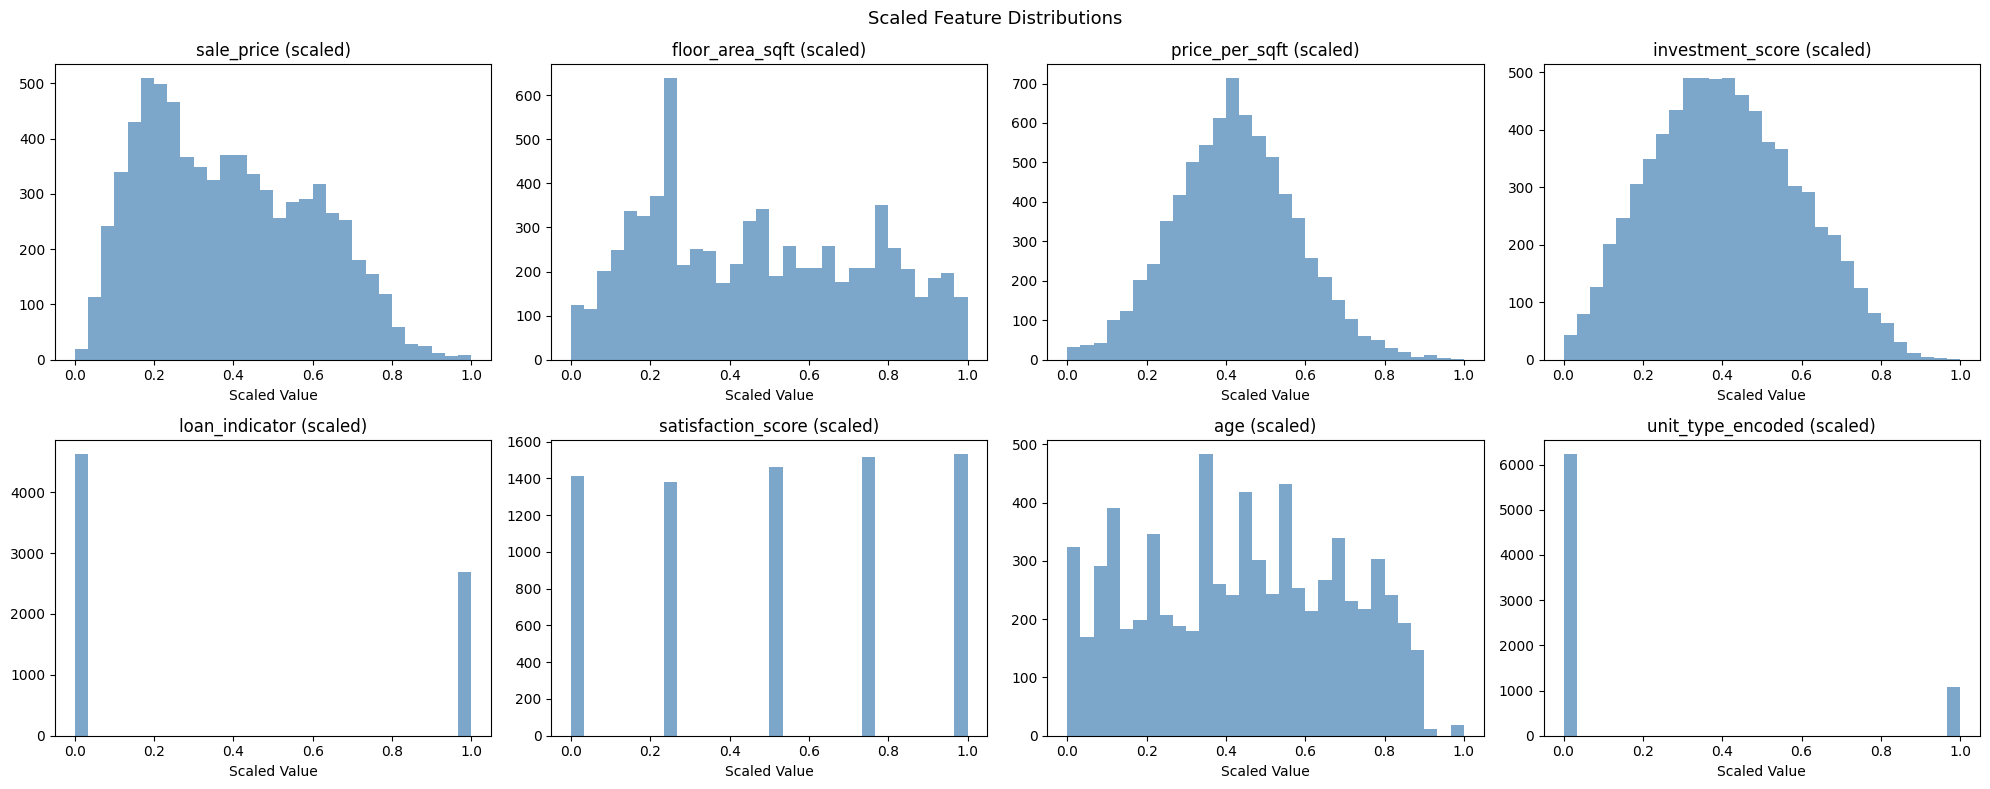

In [41]:
# Visualise scaled feature distributions
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(MODEL_FEATURES):
    axes[i].hist(scaled_df[col], bins=30, color='steelblue', alpha=0.7)
    axes[i].set_title(f'{col} (scaled)')
    axes[i].set_xlabel('Scaled Value')

plt.suptitle('Scaled Feature Distributions', fontsize=13)
plt.tight_layout()
plt.show()

## 8 · Save All Outputs

In [42]:
# Unscaled features + display cols — used as input by 03_clustering.ipynb
features_df.to_csv('../data/processed/features_dataset.csv', index=False)
print('features_dataset.csv saved:', features_df.shape)

# Scaled model features only — used for elbow/silhouette analysis
scaled_df.to_csv('../data/processed/ml_ready_dataset.csv', index=False)
print('ml_ready_dataset.csv saved:', scaled_df.shape)

# Save scaler and feature list
joblib.dump(scaler,         '../models/scaler.pkl')
joblib.dump(MODEL_FEATURES, '../models/model_feature_names.pkl')

print('scaler.pkl saved')
print('model_feature_names.pkl saved')
print('\nAll outputs saved successfully')

features_dataset.csv saved: (7305, 17)
ml_ready_dataset.csv saved: (7305, 8)
scaler.pkl saved
model_feature_names.pkl saved

All outputs saved successfully
